## Ejemplo Decision Tree MNIST
<div style="border-style:groove;border-width:thin;padding:10px">
MNIST es un dataset de 70000 dígitos numéricos escritos a mano por empleados del censo y por estudiantes de instituto de EEUU. Para poder trabajar con él, las imágenes están digitalizadas y reducidas a 28x28 pixels en blanco y negro. El objetivo de esta actividad es entrenar un modelo de clasificación que consiga determinar de que número se trata en función de los 784 datos de entrada (28x28). Cada pixel se trata como una entrada al sistema. La salida será el número del 0 al 9 que identifica. 
    </div>

<div style="border-style:groove;border-width:thin;padding:10px">
A continuación vamos a importar el dataset y a generar los conjuntos X e y.
    </div>

In [31]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [32]:
X, y = mnist["data"], mnist["target"]
print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


<div style="border-style:groove;border-width:thin;padding:10px">
Ahora vamos a coger una muestra cualquiera y a pintarlo. Los datos están como un array de una dimensión y 784 valores. Hay que cambiarlos a un array de dos dimensiones de 28x28 para poder pintarlo como una imagen. 
    </div>

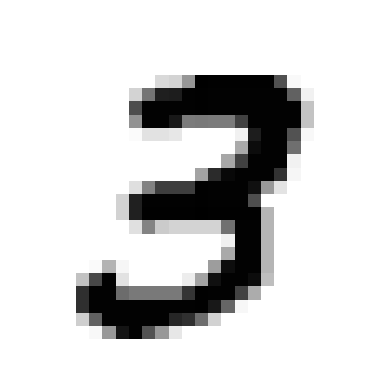

3


In [33]:
import matplotlib as mpl
import matplotlib.pyplot as plt


some_digit = X.iloc[[7]].values
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap="binary")
plt.axis("off")
plt.show()

print(y[7])

<div style="border-style:groove;border-width:thin;padding:10px">
Es tu turno! Trata de resolver el problema con un árbol de decisión siguiendo los pasos que se indican a continuación:
    </div>

<div style="border-style:groove;border-width:thin;padding:10px">
1. Divide el dataset en el conjunto de entrenamiento y de test.
    </div>

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Tamaño conjunto entrenamiento: {X_train.shape}")
print(f"Tamaño conjunto test: {X_test.shape}")

Tamaño conjunto entrenamiento: (56000, 784)
Tamaño conjunto test: (14000, 784)


<div style="border-style:groove;border-width:thin;padding:10px">
2. Crea un árbol de decisión con los parámetros que quieras e intenta mostrar el gráfico del árbol.
    </div>

In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz

#max_depth=10, min_samples_split=20, min_samples_leaf=10, random_state=42
tree_clf = DecisionTreeClassifier()
tree_clf.fit(X_train, y_train)

'''
export_graphviz(
    tree_clf,
    out_file="./iris_tree.dot",
    rounded=True,
    filled=True
)
!dot -Tpng iris_tree.dot -o iris_tree.png
'''

'\nexport_graphviz(\n    tree_clf,\n    out_file="./iris_tree.dot",\n    rounded=True,\n    filled=True\n)\n!dot -Tpng iris_tree.dot -o iris_tree.png\n'

<div style="border-style:groove;border-width:thin;padding:10px">
3. Genera la predicción (y_pred) con el árbol entrenado y mira la precisión que has conseguido. Módifica los hiperparámetros del árbol en el código del punto 2 para mejorar los resultados.
    </div>

In [36]:
from sklearn.metrics import accuracy_score

y_pred = tree_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión del árbol de decisión: {accuracy:.4f} ({accuracy*100:.2f}%)")

Precisión del árbol de decisión: 0.8729 (87.29%)


<div style="border-style:groove;border-width:thin;padding:10px">
4. Recorre la muestra de test viendo los datos que son erróneos y muestra la imagen. Evalúa si el resultado es suficientemente bueno.
</div>

Número total de errores: 1780 de 14000


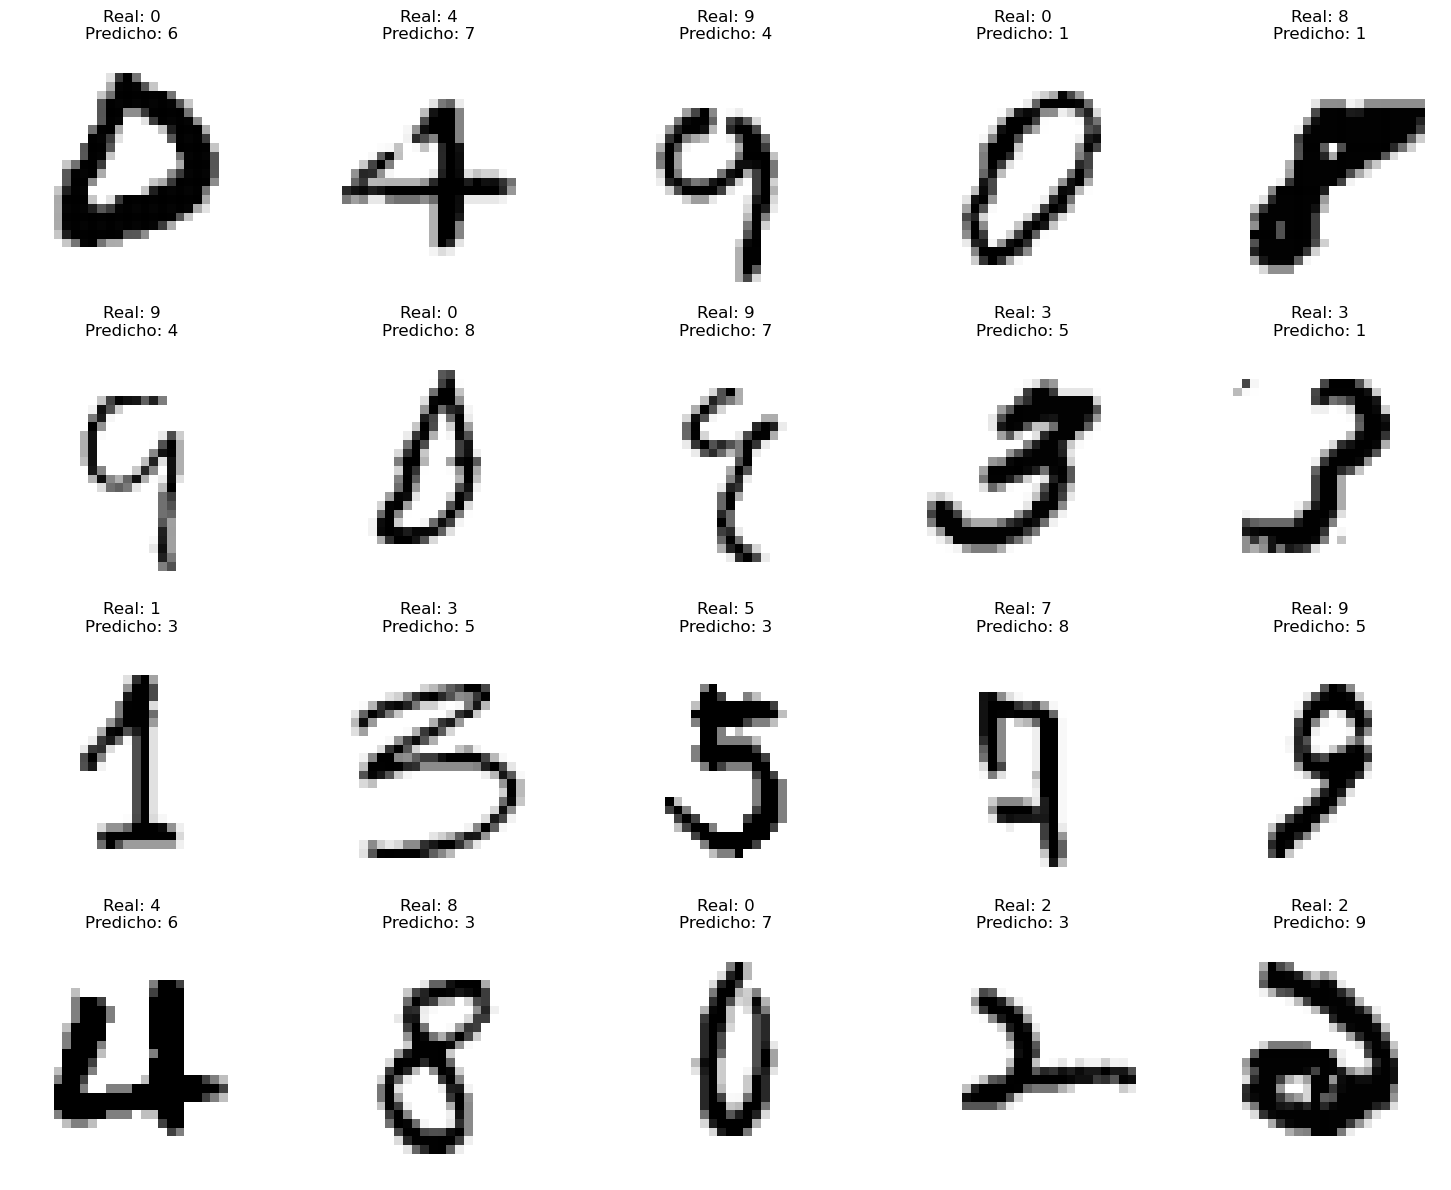

In [37]:
import numpy as np

y_test_array = y_test.values if hasattr(y_test, 'values') else y_test
errores = y_test_array != y_pred
indices_errores = np.where(errores)[0]

print(f"Número total de errores: {len(indices_errores)} de {len(y_test)}")

# Mostrar algunos ejemplos de errores
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.ravel()

for i in range(min(20, len(indices_errores))):
    idx = indices_errores[i]
    imagen = X_test.iloc[idx].values.reshape(28, 28)
    
    axes[i].imshow(imagen, cmap='binary')
    axes[i].axis('off')
    axes[i].set_title(f'Real: {y_test_array[idx]}\nPredicho: {y_pred[idx]}')

plt.tight_layout()
plt.show()

<div style="border-style:groove;border-width:thin;padding:10px">
5. Prueba ahora a resolver el problema con SVM. 
    </div>

In [ ]:
from sklearn.svm import SVC

#svm_clf = SVC(kernel="linear", C=1.0, random_state=42)
svm_clf = SVC(kernel='rbf', C=5, gamma='scale', random_state=42)
svm_clf.fit(X_train, y_train)

y_pred_svm = svm_clf.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print(f"Precisión del SVM: {accuracy_svm:.4f} ({accuracy_svm*100:.2f}%)")
print(f"Precisión del Decision Tree: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Mejora: {(accuracy_svm - accuracy)*100:.2f} puntos porcentuales")